<a href="https://colab.research.google.com/github/AndrejHorvat1/Multibeam-Forward-Looking-Sonar/blob/main/UATD_NLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
from glob import glob
import numpy as np
from skimage.metrics import structural_similarity as ssim

# Funkcija za izračun SSIM na grayscale
def compute_ssim(orig, denoised):
    gray_orig    = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
    gray_denoise = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)
    score, _ = ssim(gray_orig, gray_denoise, full=True)
    return score

h_values = [5, 10, 15]
template_values = [7, 9]
search_values = [15, 21]

test_images = sorted(glob("/content/drive/MyDrive/UATD_YOLO_Dataset_v2/images/val/*.jpg"))[:5]

results = []

for img_path in test_images:
    orig = cv2.imread(img_path)
    for h in h_values:
        for templ in template_values:
            for search in search_values:
                denoised = cv2.fastNlMeansDenoisingColored(
                    orig, None,
                    h=h, hColor=h,
                    templateWindowSize=templ,
                    searchWindowSize=search
                )
                s = compute_ssim(orig, denoised)
                results.append({
                    "img": os.path.basename(img_path),
                    "h": h,
                    "templ": templ,
                    "search": search,
                    "ssim": s
                })

results_sorted = sorted(results, key=lambda x: x["ssim"], reverse=True)

for r in results_sorted[:10]:
    print(r)

{'img': '00004.jpg', 'h': 5, 'templ': 9, 'search': 15, 'ssim': np.float64(0.9252739615149216)}
{'img': '00015.jpg', 'h': 5, 'templ': 9, 'search': 15, 'ssim': np.float64(0.9252137515245068)}
{'img': '00004.jpg', 'h': 5, 'templ': 7, 'search': 15, 'ssim': np.float64(0.9249417533796618)}
{'img': '00015.jpg', 'h': 5, 'templ': 7, 'search': 15, 'ssim': np.float64(0.9245436116099252)}
{'img': '00004.jpg', 'h': 5, 'templ': 9, 'search': 21, 'ssim': np.float64(0.9245299967943519)}
{'img': '00004.jpg', 'h': 5, 'templ': 7, 'search': 21, 'ssim': np.float64(0.9242663834074429)}
{'img': '00015.jpg', 'h': 5, 'templ': 9, 'search': 21, 'ssim': np.float64(0.9241148743200995)}
{'img': '00015.jpg', 'h': 5, 'templ': 7, 'search': 21, 'ssim': np.float64(0.9234961150845042)}
{'img': '00008.jpg', 'h': 5, 'templ': 9, 'search': 15, 'ssim': np.float64(0.9217562435692054)}
{'img': '00008.jpg', 'h': 5, 'templ': 7, 'search': 15, 'ssim': np.float64(0.9211181882902011)}


In [ ]:
for r in results_sorted:
    print(r)

{'img': '00004.jpg', 'h': 5, 'templ': 9, 'search': 15, 'ssim': np.float64(0.9252739615149216)}
{'img': '00015.jpg', 'h': 5, 'templ': 9, 'search': 15, 'ssim': np.float64(0.9252137515245068)}
{'img': '00004.jpg', 'h': 5, 'templ': 7, 'search': 15, 'ssim': np.float64(0.9249417533796618)}
{'img': '00015.jpg', 'h': 5, 'templ': 7, 'search': 15, 'ssim': np.float64(0.9245436116099252)}
{'img': '00004.jpg', 'h': 5, 'templ': 9, 'search': 21, 'ssim': np.float64(0.9245299967943519)}
{'img': '00004.jpg', 'h': 5, 'templ': 7, 'search': 21, 'ssim': np.float64(0.9242663834074429)}
{'img': '00015.jpg', 'h': 5, 'templ': 9, 'search': 21, 'ssim': np.float64(0.9241148743200995)}
{'img': '00015.jpg', 'h': 5, 'templ': 7, 'search': 21, 'ssim': np.float64(0.9234961150845042)}
{'img': '00008.jpg', 'h': 5, 'templ': 9, 'search': 15, 'ssim': np.float64(0.9217562435692054)}
{'img': '00008.jpg', 'h': 5, 'templ': 7, 'search': 15, 'ssim': np.float64(0.9211181882902011)}
{'img': '00008.jpg', 'h': 5, 'templ': 9, 'search':

In [ ]:
import os
import cv2
import shutil
from glob import glob

augmented_base = "/content/drive/MyDrive/UATD_YOLO_Dataset_v2"
output_base    = "/content/drive/MyDrive/UATD_YOLO_Dataset_NLM"

for subset in ["train", "val"]:
    os.makedirs(os.path.join(output_base, f"images/{subset}"), exist_ok=True)
    os.makedirs(os.path.join(output_base, f"labels/{subset}"), exist_ok=True)

nlm_h       = 10   # jačina denoisinga po intenzitetu
nlm_hColor  = 10   # jačina denoisinga za boju
nlm_templ   = 9    # templateWindowSize
nlm_search  = 15   # searchWindowSize

for subset in ["train", "val"]:
    img_paths = sorted(glob(os.path.join(augmented_base, f"images/{subset}/*.jpg")))

    for img_path in img_paths:
        img_name  = os.path.basename(img_path)
        img_id    = os.path.splitext(img_name)[0]
        label_src = os.path.join(augmented_base, f"labels/{subset}/{img_id}.txt")
        label_dst = os.path.join(output_base,     f"labels/{subset}/{img_id}.txt")

        if not os.path.exists(label_src):
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"Ne mogu učitati {img_path}, preskačem…")
            continue

        denoised = cv2.fastNlMeansDenoisingColored(
            img, None,
            h=nlm_h, hColor=nlm_hColor,
            templateWindowSize=nlm_templ,
            searchWindowSize=nlm_search
        )

        out_img_path = os.path.join(output_base, f"images/{subset}/{img_name}")
        cv2.imwrite(out_img_path, denoised)

        shutil.copy(label_src, label_dst)

        print(f"{subset}/{img_name} → (NLM) spremljeno.")

print("\nDenoising (NLM) završen. Podaci su u:")

Izlaz streaminga skraćen je na ovoliko posljednjih redaka: 5000.
train/06387.jpg → (NLM) spremljeno.
train/06387_aug.jpg → (NLM) spremljeno.
train/06389.jpg → (NLM) spremljeno.
train/06389_aug.jpg → (NLM) spremljeno.
train/06390.jpg → (NLM) spremljeno.
train/06390_aug.jpg → (NLM) spremljeno.
train/06391.jpg → (NLM) spremljeno.
train/06391_aug.jpg → (NLM) spremljeno.
train/06392.jpg → (NLM) spremljeno.
train/06392_aug.jpg → (NLM) spremljeno.
train/06393.jpg → (NLM) spremljeno.
train/06393_aug.jpg → (NLM) spremljeno.
train/06395.jpg → (NLM) spremljeno.
train/06395_aug.jpg → (NLM) spremljeno.
train/06397.jpg → (NLM) spremljeno.
train/06397_aug.jpg → (NLM) spremljeno.
train/06398.jpg → (NLM) spremljeno.
train/06398_aug.jpg → (NLM) spremljeno.
train/06399.jpg → (NLM) spremljeno.
train/06399_aug.jpg → (NLM) spremljeno.
train/06400.jpg → (NLM) spremljeno.
train/06400_aug.jpg → (NLM) spremljeno.
train/06402.jpg → (NLM) spremljeno.
train/06402_aug.jpg → (NLM) spremljeno.
train/06403.jpg → (NLM)

In [ ]:
import os
import cv2
import shutil
from glob import glob

test_sets = ["test_set1", "test_set2"]

original_base = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_v2"
output_base   = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_NLM"

nlm_h       = 10    # jačina denoisinga (intenzitet)
nlm_hColor  = 10    # jačina denoisinga (boja)
nlm_templ   = 9    # templateWindowSize
nlm_search  = 15   # searchWindowSize

for set_name in test_sets:
    inp_img_dir = os.path.join(original_base, "images", set_name)
    inp_lbl_dir = os.path.join(original_base, "labels", set_name)

    out_img_dir = os.path.join(output_base, "images", set_name)
    out_lbl_dir = os.path.join(output_base, "labels", set_name)

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    image_paths = sorted(glob(os.path.join(inp_img_dir, "*.jpg")))

    for img_path in image_paths:
        img_name = os.path.basename(img_path)
        img_id   = os.path.splitext(img_name)[0]
        lbl_src  = os.path.join(inp_lbl_dir, img_id + ".txt")
        if not os.path.exists(lbl_src):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        denoised = cv2.fastNlMeansDenoisingColored(
            img, None,
            h=nlm_h, hColor=nlm_hColor,
            templateWindowSize=nlm_templ,
            searchWindowSize=nlm_search
        )

        cv2.imwrite(os.path.join(out_img_dir, img_name), denoised)

        shutil.copy(lbl_src, os.path.join(out_lbl_dir, img_id + ".txt"))

        print(f"{set_name}/{img_name} spremljeno.")

print("\nNLM test skup gotov", output_base)


test_set1/00001.jpg spremljeno.
test_set1/00002.jpg spremljeno.
test_set1/00003.jpg spremljeno.
test_set1/00004.jpg spremljeno.
test_set1/00005.jpg spremljeno.
test_set1/00006.jpg spremljeno.
test_set1/00007.jpg spremljeno.
test_set1/00008.jpg spremljeno.
test_set1/00009.jpg spremljeno.
test_set1/00010.jpg spremljeno.
test_set1/00011.jpg spremljeno.
test_set1/00012.jpg spremljeno.
test_set1/00013.jpg spremljeno.
test_set1/00014.jpg spremljeno.
test_set1/00015.jpg spremljeno.
test_set1/00016.jpg spremljeno.
test_set1/00017.jpg spremljeno.
test_set1/00018.jpg spremljeno.
test_set1/00019.jpg spremljeno.
test_set1/00020.jpg spremljeno.
test_set1/00021.jpg spremljeno.
test_set1/00022.jpg spremljeno.
test_set1/00023.jpg spremljeno.
test_set1/00024.jpg spremljeno.
test_set1/00025.jpg spremljeno.
test_set1/00026.jpg spremljeno.
test_set1/00027.jpg spremljeno.
test_set1/00028.jpg spremljeno.
test_set1/00029.jpg spremljeno.
test_set1/00030.jpg spremljeno.
test_set1/00031.jpg spremljeno.
test_set

In [2]:
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_NLM" /content/
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_Test_NLM" /content/

In [3]:
data_yaml = """train: /content/UATD_YOLO_Dataset_NLM/images/train
val: /content/UATD_YOLO_Dataset_NLM//images/val
nc: 10
test:
  - /content/UATD_YOLO_Dataset_Test_NLM//images/test_set1
  - /content/UATD_YOLO_Dataset_Test_NLM//images/test_set2
names: ['cube', 'ball', 'cylinder', 'human body', 'plane', 'circle cage', 'square cage', 'metal bucket', 'tyre', 'rov']
"""

os.makedirs("yolo_dataset", exist_ok=True)

with open("yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

In [4]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [6]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os

DATA_YAML_PATH = "yolo_dataset/data.yaml"
INITIAL_WEIGHTS = "yolov8s.pt"
model = YOLO(INITIAL_WEIGHTS)

model.train(data=DATA_YAML_PATH, epochs=15, batch=8, imgsz=640, project="runs", name="custom_loop", verbose=True, exist_ok=True)

100%|██████████| 21.5M/21.5M [00:00<00:00, 218MB/s]


Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_loop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=T

100%|██████████| 755k/755k [00:00<00:00, 22.5MB/s]

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

 18                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 19                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  1   1969152  ultralytics.nn.modules.block.C2f             [768, 512, 1]                 
 22        [15, 18, 21]  1   2119918  ultralytics.nn.modules.head.Detect           [10, [128, 256, 512]]         
Model summary: 129 layers, 11,139,470 parameters, 11,139,454 gradients, 28.7 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


...

      15/15         3G      1.353     0.5737      1.031          9        640: 100%|██████████| 1518/1518 [05:11<00:00,  4.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [00:35<00:00,  5.38it/s]


                   all       3038       4954      0.961      0.933      0.956      0.563

15 epochs completed in 1.407 hours.
Optimizer stripped from runs/custom_loop/weights/last.pt, 22.5MB
Optimizer stripped from runs/custom_loop/weights/best.pt, 22.5MB

Validating runs/custom_loop/weights/best.pt...
Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [00:37<00:00,  5.09it/s]


                   all       3038       4954      0.961      0.933      0.956      0.563
                  cube       1050       1052      0.968      0.964      0.971       0.59
                  ball       1210       1212      0.974       0.95      0.965      0.567
              cylinder        226        226      0.916      0.913      0.961      0.502
            human body        556        558      0.972      0.947      0.957      0.557
                 plane        334        334      0.981      0.982      0.992      0.681
           circle cage        282        284       0.91      0.889      0.867      0.525
           square cage        376        376      0.988      0.941      0.971      0.554
          metal bucket        194        194      0.981      0.943      0.965      0.542
                  tyre        454        458      0.954      0.861      0.927      0.556
                   rov        260        260      0.969      0.935      0.985      0.554
Speed: 0.2ms preproce

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ddd798f7290>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [7]:
metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=640, batch=8)

Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.6±24.2 MB/s, size: 142.6 KB)


val: Scanning /content/UATD_YOLO_Dataset_Test_NLM/labels/test_set1... 1596 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1596/1596 [00:03<00:00, 425.60it/s]

val: New cache created: /content/UATD_YOLO_Dataset_Test_NLM/labels/test_set1.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 200/200 [00:25<00:00,  7.96it/s]


                   all       1596       2323      0.853      0.836      0.829       0.37
                  cube        338        338      0.658      0.902      0.722      0.256
                  ball        390        390       0.82      0.879       0.81      0.433
              cylinder         93         93      0.951      0.914      0.945      0.371
            human body        149        149      0.837      0.913      0.906      0.403
                 plane        269        269      0.989      0.985      0.994      0.683
           circle cage        197        197      0.699      0.437      0.564      0.244
           square cage        335        335      0.807      0.615      0.615      0.191
          metal bucket         11         11      0.881      0.909      0.855      0.243
                  tyre        241        241      0.906      0.843      0.889      0.359
                   rov        300        300       0.98      0.965       0.99      0.516
Speed: 0.5ms preproce

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 21.5M/21.5M [00:00<00:00, 120MB/s] 



 Epoha 1/15
Ultralytics 8.3.148 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_loop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 25.0MB/s]

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

...

                   all       3038       4954        0.9      0.862      0.899      0.454

1 epochs completed in 0.105 hours.
Optimizer stripped from runs/custom_loop/weights/last.pt, 22.5MB
Optimizer stripped from runs/custom_loop/weights/best.pt, 22.5MB

Validating runs/custom_loop/weights/best.pt...
Ultralytics 8.3.148 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [00:37<00:00,  5.11it/s]


                   all       3038       4954      0.898      0.863      0.899      0.454
                  cube       1050       1052      0.889      0.907      0.915      0.476
                  ball       1210       1212      0.948      0.914      0.927      0.484
              cylinder        226        226      0.806      0.646      0.804      0.394
            human body        556        558      0.908      0.886      0.907        0.4
                 plane        334        334      0.932      0.946       0.96      0.573
           circle cage        282        284      0.904      0.824      0.851       0.46
           square cage        376        376       0.96      0.902      0.928      0.429
          metal bucket        194        194      0.932      0.916      0.938       0.46
                  tyre        454        458      0.851      0.753      0.832      0.441
                   rov        260        260      0.853      0.935       0.93      0.419
Speed: 0.3ms preproce

val: Scanning /content/UATD_YOLO_Dataset_Test_NLM/labels/test_set1.cache... 1596 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1596/1596 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 200/200 [00:24<00:00,  8.17it/s]


                   all       1596       2323      0.814      0.776      0.779      0.318
                  cube        338        338      0.631      0.882      0.615      0.227
                  ball        390        390      0.816      0.864      0.814      0.414
              cylinder         93         93       0.89      0.696      0.854      0.318
            human body        149        149      0.742      0.872       0.81        0.3
                 plane        269        269      0.962      0.936      0.974       0.56
           circle cage        197        197      0.648      0.355      0.526       0.21
           square cage        335        335      0.821      0.603       0.58      0.199
          metal bucket         11         11      0.907      0.891      0.859      0.211
                  tyre        241        241      0.831      0.776      0.837      0.339
                   rov        300        300      0.896      0.887      0.918      0.406
Speed: 0.5ms preproce

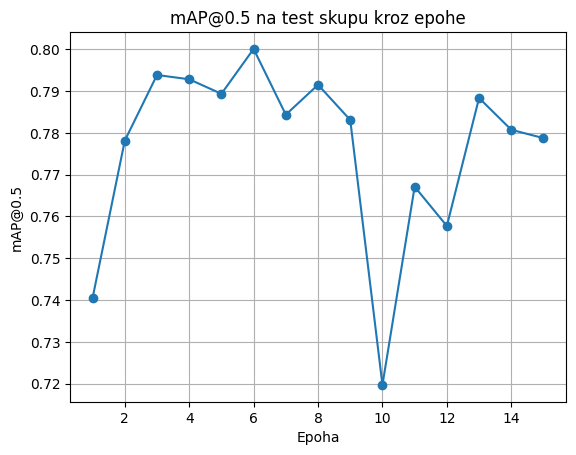

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os

# Konfiguracija
DATA_YAML_PATH = "yolo_dataset/data.yaml"
BEST_MODEL_PATH = "best_yolov8.pt"
INITIAL_WEIGHTS = "yolov8s.pt"
EPOCHS = 15

# Inicijaliziraj model
model = YOLO(INITIAL_WEIGHTS)
map_scores = []
best_map = 0.0

# Loop po epohama
for epoch in range(EPOCHS):
    print(f"\n Epoha {epoch + 1}/{EPOCHS}")

    # Treniraj samo 1 epohu
    model.train(data=DATA_YAML_PATH, epochs=1, batch=8, imgsz=640, project="runs", name="custom_loop", verbose=True, exist_ok=True)

    # Validacija na test skupu
    metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=640, batch=8)

    # Dohvati mAP@0.5 i dodaj u listu
    map_50 = metrics.box.map50  # float
    print(f"mAP@0.5 test: {map_50:.4f}")
    map_scores.append(map_50)


# Plotanje rezultata
plt.plot(range(1, EPOCHS + 1), map_scores, marker='o')
plt.title("mAP@0.5 na test skupu kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("mAP@0.5")
plt.grid(True)
plt.show()


!cp -r runs/custom_loop /content/drive/MyDrive/yolov8_NLM/

In [8]:
!cp -r runs/custom_loop /content/drive/MyDrive/yolov8_NLM_noTest/